# 🛰️ AFETSONAR — Notebook 1c: xBD Tier 3 Ekleme

**Calamitas AI · Teknofest 2025 · Veri Setini Genişletme**

---

## 📌 Bu Notebook Neden Var?

Phase 2 sonuçları **0.4048 mIoU_no_bg** verdi — iyi ama overfit belirtisi var:
- Train loss: 0.48 (azalmaya devam)
- Val loss: 0.73 (~epoch 10'dan beri sabit)
- **train/val gap büyüyor** = klasik az veri overfit'i

Tek doğru çözüm: **daha çok veri**.

## 🔍 Neden Sadece Tier 3?

Sen başta birçok dataset önerdin (AID, DOTA, Inria, Nepal vs.). Hepsini araştırdım, gerçek sonuç:

| Dataset | Karar | Sebep |
|---|---|---|
| **xBD Tier 3** ✅ | EKLE | Aynı format, aynı görev, +6500 görüntü |
| AID, UC Merced | ❌ | Sahne sınıflandırma, segmentation değil |
| DOTA, xView | ❌ | Object detection, hasar yok |
| Inria Aerial | ❌ | Hasar etiketi yok, sadece bina var/yok |
| DeepGlobe | ❌ | Land cover, bina değil |
| Nepal/Ecuador/L'Aquila | ❌ | Format çok farklı, manuel re-mapping = haftalar |
| RescueNet | ❌ | Drone foto (uydu değil), post-only |
| EIDSeg | ❌ | Sosyal medya foto, yer-seviyesi |
| QuickQuakeBuildings | ❌ | SAR farklı sensor, binary |

**Sadece Tier 3** → ROI en yüksek, aynı format, sıfır manuel iş.

> **Bilimsel kanıt:** xView2 challenge **kazananı (Durnov, 2020)** sadece xBD train+tier3 = 9168 görüntü kullandı. SoTA sadece bunu kullanıyor.

## 📊 Tier 1 vs Tier 3 Karşılaştırma

| | Tier 1 (mevcut) | Tier 3 (yeni) | Toplam |
|---|---|---|---|
| Görüntü | 2,799 | ~6,500 | **~9,300** |
| Boyut | ~7 GB | ~22 GB | ~29 GB |
| Disaster sayısı | 11 | 8 (yeni) | 19 |
| Format | Aynı | Aynı | ✅ |

**Yeni disasterlar** Tier 3'te (Tier 1'de olmayan):
- Joplin tornado
- Lower Puna volcanic eruption
- Moore tornado
- Pinery bushfire
- Portugal wildfire
- Sunda tsunami
- Tuscaloosa tornado
- Woolsey fire

Bu Tier 1'in **disaster çeşitliliği**ni 2x artırıyor. Özellikle **tornado ve volkan** verisi ekleyecek (Türkiye için kritik değil ama model genelleştirmesi için iyi).

## ⏱️ Süre

| Adım | Süre |
|---|---|
| Kaggle download (~22 GB) | ~30 dakika |
| Maskeleme + index | ~20 dakika |
| Yeni split CSV oluşturma | ~5 dakika |
| **Toplam** | **~1 saat** |

## ⚠️ Önemli

Bu notebook **mevcut Tier 1 verilerine DOKUNMAZ**. Tier 3'ü ayrı klasöre indirir, sonra **birleştirilmiş yeni splitler** oluşturur:
- Eski: `train_v2.csv`, `val_v2.csv`, `test_v2.csv` (Tier 1 only)
- Yeni: `train_v3.csv`, `val_v3.csv`, `test_v3.csv` (Tier 1 + Tier 3)

Phase 2'yi yeniden eğitirken yeni `train_v3.csv` kullanılacak.

## 🔧 Kaggle Setup Gerekli

xBD Tier 3 Kaggle'da. Notebook 1'de zaten Kaggle'ı kurmuştuk. Eğer hala token Drive'da varsa, yeniden setup'a gerek yok.

---

## 1️⃣ Drive + Yollar

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

PROJECT_ROOT = "/content/drive/MyDrive/AFETSONAR"
DATA_RAW     = os.path.join(PROJECT_ROOT, "data/raw/xview2")
DATA_TIER3   = os.path.join(PROJECT_ROOT, "data/raw/xview2_tier3")  # YENİ
DATA_MASKS   = os.path.join(PROJECT_ROOT, "data/processed/masks")
DATA_SPLITS  = os.path.join(PROJECT_ROOT, "data/splits")
SRC_DIR      = os.path.join(PROJECT_ROOT, "src")
OUTPUTS_VIZ  = os.path.join(PROJECT_ROOT, "outputs/visualizations")

print("✅ Drive bağlandı")
print()
print("📁 Mevcut yapı:")
for p in [DATA_RAW, DATA_MASKS, DATA_SPLITS]:
    marker = "✅" if os.path.exists(p) else "❌"
    print(f"  {marker} {p}")

# Tier 3 klasörünü oluştur
os.makedirs(DATA_TIER3, exist_ok=True)
print(f"\n📁 Yeni Tier 3 klasör: {DATA_TIER3}")

# Mevcut tier 1 görüntü sayısı kontrol
import pandas as pd
file_index_v2 = os.path.join(DATA_SPLITS, "file_index_v2.csv")
if os.path.exists(file_index_v2):
    df_v2 = pd.read_csv(file_index_v2)
    print(f"\n📊 Mevcut Tier 1: {len(df_v2)} görüntü")
else:
    print("\n⚠️  file_index_v2.csv bulunamadı")

Mounted at /content/drive
✅ Drive bağlandı

📁 Mevcut yapı:
  ✅ /content/drive/MyDrive/AFETSONAR/data/raw/xview2
  ✅ /content/drive/MyDrive/AFETSONAR/data/processed/masks
  ✅ /content/drive/MyDrive/AFETSONAR/data/splits

📁 Yeni Tier 3 klasör: /content/drive/MyDrive/AFETSONAR/data/raw/xview2_tier3

📊 Mevcut Tier 1: 2799 görüntü


## 2️⃣ Kaggle Token Kontrolü

Notebook 1'de Kaggle token'ı yüklemiştin. Drive'da varsa kullanırız, yoksa yeniden yüklemen gerekecek.

In [3]:
import os
import shutil

# Kaggle token'ı Drive'da kontrol et
kaggle_token_drive = os.path.join(PROJECT_ROOT, "kaggle.json")
kaggle_dir = os.path.expanduser("~/.kaggle")
kaggle_token_local = os.path.join(kaggle_dir, "kaggle.json")

os.makedirs(kaggle_dir, exist_ok=True)

if os.path.exists(kaggle_token_drive):
    shutil.copy(kaggle_token_drive, kaggle_token_local)
    os.chmod(kaggle_token_local, 0o600)
    print(f"✅ Kaggle token bulundu ve yüklendi")
else:
    print("⚠️  Kaggle token Drive'da yok")
    print()
    print("LÜTFEN YAPILMASI GEREKEN:")
    print("1. https://www.kaggle.com/settings/account → Create New API Token")
    print("2. İndirilen kaggle.json dosyasını yükle:")
    print()
    from google.colab import files
    uploaded = files.upload()
    if "kaggle.json" in uploaded:
        with open(kaggle_token_local, "wb") as f:
            f.write(uploaded["kaggle.json"])
        os.chmod(kaggle_token_local, 0o600)
        # Drive'a da yedekle
        shutil.copy(kaggle_token_local, kaggle_token_drive)
        print(f"✅ Token yüklendi ve Drive'a yedeklendi")
    else:
        raise FileNotFoundError("kaggle.json yüklenmedi")

# Kaggle CLI kontrol
import subprocess
result = subprocess.run(["kaggle", "--version"], capture_output=True, text=True)
print(f"\n🔧 Kaggle CLI: {result.stdout.strip()}")

✅ Kaggle token bulundu ve yüklendi

🔧 Kaggle CLI: Kaggle CLI 2.0.0


## 3️⃣ xBD Tier 3'ü İndir

Kaggle'da xView2 dataset'i tek paket olarak var. Tier 3 ayrı bir dataset:

`kaggle datasets download -d shahid-ahsan/xview2-tier3` (eğer varsa)

Veya manuel mirror'lardan indirme deneriz. **Bu adım ~30 dk sürer**.

### Dataset Adı

xView2 Tier 3 için Kaggle'da birkaç mirror var. En güveniliri **xview2-challenge tier3 mirror**.

In [4]:
import os
import subprocess

# xBD Tier 3 dataset alternatifleri (Kaggle'da)
# 1. Resmi xview2 challenge dataset (Tier 1 + Tier 3 toplam)
# 2. Spesifik tier 3 mirror

# Önce indirilmemiş mi kontrol
existing_disasters = [d for d in os.listdir(DATA_TIER3) if os.path.isdir(os.path.join(DATA_TIER3, d))] if os.path.exists(DATA_TIER3) else []
if existing_disasters:
    print(f"⚠️  Tier 3 zaten indirilmiş gibi görünüyor:")
    for d in existing_disasters:
        print(f"  - {d}")
    print(f"\nİndirilenleri silmek istiyorsan: !rm -rf {DATA_TIER3}/*")
    print("Yeniden indirmek için aşağıyı çalıştır:")

# === Yöntem 1: Kaggle dataset olarak indir ===
print("\n📥 Tier 3 indiriliyor...")
print("   ~22 GB, ~30 dk sürebilir")
print("=" * 60)

os.chdir(DATA_TIER3)

# DOĞRU Kaggle dataset adı: tunguz/xview2-challenge-dataset-tier-3-data
# Bu dataset Kaggle'da gerçekten mevcut (Bojan Tunguz tarafından upload edilmiş)
download_commands = [
    # YÖNTEM A: Doğru Kaggle dataset adı
    ["kaggle", "datasets", "download", "-d", "tunguz/xview2-challenge-dataset-tier-3-data", "--unzip"],
    # YÖNTEM B: Yedek olarak train+test mirror (sadece tier 1 verir, ama emin olmak için)
    # ["kaggle", "datasets", "download", "-d", "tunguz/xview2-challenge-dataset-train-and-test", "--unzip"],
]

success = False
for cmd in download_commands:
    print(f"\n🔄 Denenen: {' '.join(cmd)}")
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=3600)
        if result.returncode == 0:
            print("   ✅ Başarılı")
            success = True
            break
        else:
            print(f"   ❌ Hata: {result.stderr[:200]}")
    except subprocess.TimeoutExpired:
        print("   ⏱️  Timeout (1 saat)")
    except Exception as e:
        print(f"   ❌ Exception: {e}")

if not success:
    print("\n⚠️  Otomatik indirme başarısız.")
    print("MANUAL İNDİRME:")
    print("1. https://www.kaggle.com/datasets adresine git")
    print("2. 'xview2 tier3' veya 'xBD tier3' ara")
    print("3. İndirilen zip'i Drive'a yükle")
    print(f"4. /content/drive/MyDrive/AFETSONAR/data/raw/xview2_tier3/ klasörüne çıkart")
    print()
    print("ALTERNATİF: Resmi xView2 sitesinden:")
    print("https://xview2.org/dataset (kayıt gerekli)")

# Klasörü kontrol et
os.chdir("/content")
if os.path.exists(DATA_TIER3):
    contents = os.listdir(DATA_TIER3)
    print(f"\n📦 Tier 3 klasör içeriği ({len(contents)} öğe):")
    for c in sorted(contents)[:20]:
        full = os.path.join(DATA_TIER3, c)
        if os.path.isdir(full):
            sub_count = len(os.listdir(full)) if os.access(full, os.R_OK) else 0
            print(f"  📁 {c}/  ({sub_count} öğe)")
        else:
            size_mb = os.path.getsize(full) / 1024**2
            print(f"  📄 {c}  ({size_mb:.1f} MB)")

⚠️  Tier 3 zaten indirilmiş gibi görünüyor:
  - tier3

İndirilenleri silmek istiyorsan: !rm -rf /content/drive/MyDrive/AFETSONAR/data/raw/xview2_tier3/*
Yeniden indirmek için aşağıyı çalıştır:

📥 Tier 3 indiriliyor...
   ~22 GB, ~30 dk sürebilir

🔄 Denenen: kaggle datasets download -d tunguz/xview2-challenge-dataset-tier-3-data --unzip
   ⏱️  Timeout (1 saat)

⚠️  Otomatik indirme başarısız.
MANUAL İNDİRME:
1. https://www.kaggle.com/datasets adresine git
2. 'xview2 tier3' veya 'xBD tier3' ara
3. İndirilen zip'i Drive'a yükle
4. /content/drive/MyDrive/AFETSONAR/data/raw/xview2_tier3/ klasörüne çıkart

ALTERNATİF: Resmi xView2 sitesinden:
https://xview2.org/dataset (kayıt gerekli)

📦 Tier 3 klasör içeriği (2 öğe):
  📁 tier3/  (2 öğe)
  📄 xview2-challenge-dataset-tier-3-data.zip  (17732.3 MB)


## 4️⃣ Tier 3 Yapısını Doğrula

Beklenen klasör yapısı (xBD standard):

```
xview2_tier3/
├── joplin-tornado/
│   ├── images/
│   │   ├── *_pre_disaster.png
│   │   └── *_post_disaster.png
│   └── labels/
│       └── *.json
├── lower-puna-volcano/
│   └── ...
└── ...
```

Eğer farklı bir yapıda gelirse, normalize ediyoruz.

In [5]:
import os
import json
from pathlib import Path

# Tier 3 yapısını analiz et
print("🔍 Tier 3 yapı analizi...")
print("=" * 60)

tier3_disasters = {}
total_images = 0
total_labels = 0

# Bütün PNG ve JSON dosyalarını recursively bul
for root, dirs, files in os.walk(DATA_TIER3):
    for f in files:
        if f.endswith("_pre_disaster.png") or f.endswith("_post_disaster.png"):
            # Disaster adını dosya adından çıkar
            # Format: <disaster>_<id>_<pre|post>_disaster.png
            parts = f.split("_")
            if len(parts) >= 3:
                # Disaster ismini path'ten alabilirsin
                rel_path = os.path.relpath(root, DATA_TIER3)
                if rel_path == ".":
                    # Dosya doğrudan tier3 root'ta
                    disaster = parts[0]
                else:
                    disaster = rel_path.split("/")[0]

                if disaster not in tier3_disasters:
                    tier3_disasters[disaster] = {"images": 0, "labels": 0}
                tier3_disasters[disaster]["images"] += 1
                total_images += 1

        elif f.endswith(".json"):
            rel_path = os.path.relpath(root, DATA_TIER3)
            if rel_path == ".":
                continue
            disaster = rel_path.split("/")[0]
            if disaster in tier3_disasters:
                tier3_disasters[disaster]["labels"] += 1
                total_labels += 1

if not tier3_disasters:
    print("❌ Hiçbir Tier 3 dosyası bulunamadı!")
    print(f"   Kontrol edilen yol: {DATA_TIER3}")
    print(f"   İndirme tamamlanmış mı?")
    raise FileNotFoundError("Tier 3 verisi yok")

print(f"📊 Bulunan disasterlar: {len(tier3_disasters)}")
print(f"   Toplam image (pre+post): {total_images}")
print(f"   Toplam label: {total_labels}")
print()

print(f"{'Disaster':<25s} {'Images':>10s} {'Labels':>10s}")
print("-" * 50)
for disaster, counts in sorted(tier3_disasters.items()):
    n_images = counts["images"]
    n_labels = counts["labels"]
    n_pairs = n_images // 2  # pre+post pair
    print(f"{disaster:<25s} {n_images:>10d} {n_labels:>10d}")

# Beklenen pair sayısı
total_pairs = total_images // 2
print(f"\n💡 Toplam pre/post çift: ~{total_pairs}")

🔍 Tier 3 yapı analizi...
📊 Bulunan disasterlar: 1
   Toplam image (pre+post): 12738
   Toplam label: 12738

Disaster                      Images     Labels
--------------------------------------------------
tier3                          12738      12738

💡 Toplam pre/post çift: ~6369


## 5️⃣ Disaster Türü Eşleme

Tier 3'teki disaster isimleri Tier 1'den farklı. Bunları bizim 5 kategoriye eşliyoruz:

| Tier 3 disaster | Bizim kategori |
|---|---|
| joplin-tornado | kasirga (tornado ≈ kasırga, geniş hasar tipi) |
| moore-tornado | kasirga |
| tuscaloosa-tornado | kasirga |
| lower-puna-volcano | yangin (volkanik yangın) |
| pinery-bushfire | yangin |
| portugal-wildfire | yangin |
| woolsey-fire | yangin |
| sunda-tsunami | tsunami |

Tornado'lar için ayrı bir kategori açabilirdik ama 5 disaster type'ı korumak istiyoruz (model değişmemesi için). Tornado fiziksel hasar tipi olarak kasırgaya en yakın.

In [6]:
# Tier 3 disaster -> Bizim kategori mapping
TIER3_DISASTER_MAP = {
    "joplin-tornado": "kasirga",
    "moore-tornado": "kasirga",
    "tuscaloosa-tornado": "kasirga",
    "lower-puna-volcano": "yangin",  # volkanik aktivite
    "pinery-bushfire": "yangin",
    "portugal-wildfire": "yangin",
    "woolsey-fire": "yangin",
    "sunda-tsunami": "tsunami",
    # Backup: bilinmeyen disaster için varsayılan
}

DISASTER_TO_IDX = {
    "deprem":  0,
    "sel":     1,
    "yangin":  2,
    "kasirga": 3,
    "tsunami": 4,
}

print("🗺️  Tier 3 disaster mapping:")
for tier3, our_cat in TIER3_DISASTER_MAP.items():
    print(f"  {tier3:<25s} → {our_cat}")

# Bulunan disasterleri kontrol et
unmapped = []
for disaster in tier3_disasters.keys():
    if disaster not in TIER3_DISASTER_MAP:
        unmapped.append(disaster)

if unmapped:
    print(f"\n⚠️  Eşlenmemiş {len(unmapped)} disaster bulundu:")
    for d in unmapped:
        print(f"   - {d}")
    print("\nVarsayılan: 'kasirga' (yapısal hasar)")
    for d in unmapped:
        TIER3_DISASTER_MAP[d] = "kasirga"

🗺️  Tier 3 disaster mapping:
  joplin-tornado            → kasirga
  moore-tornado             → kasirga
  tuscaloosa-tornado        → kasirga
  lower-puna-volcano        → yangin
  pinery-bushfire           → yangin
  portugal-wildfire         → yangin
  woolsey-fire              → yangin
  sunda-tsunami             → tsunami

⚠️  Eşlenmemiş 1 disaster bulundu:
   - tier3

Varsayılan: 'kasirga' (yapısal hasar)


## 6️⃣ Tier 3 Maskelerini Üret

Notebook 1b'deki mantıkla aynı: 6 sınıflı maskeler (un-classified=5).

Maskeler aynı `data/processed/masks/` klasörüne yazılır (Tier 1'le birlikte).

In [7]:
import cv2
import numpy as np
import json
from tqdm.auto import tqdm

# Damage class mapping (notebook 1b ile aynı)
DAMAGE_MAP_V2 = {
    "no-damage":     1,
    "minor-damage":  2,
    "major-damage":  3,
    "destroyed":     4,
    "un-classified": 5,
}

def create_mask_from_json_v2(image_path, json_path, output_path):
    try:
        img = cv2.imread(image_path)
        if img is None:
            return {"success": False, "class_counts": None}
        h, w = img.shape[:2]
        mask = np.zeros((h, w), dtype=np.uint8)

        with open(json_path, 'r') as f:
            data = json.load(f)

        building_count = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0}

        for feature in data.get('features', {}).get('xy', []):
            try:
                wkt = feature['wkt']
                coords_str = wkt.replace("POLYGON ((", "").replace("))", "")
                if "), (" in coords_str:
                    coords_str = coords_str.split("), (")[0]
                coords = coords_str.split(", ")
                pts = np.array(
                    [list(map(float, pt.split())) for pt in coords],
                    dtype=np.int32
                )

                subtype = feature.get('properties', {}).get('subtype', 'no-damage')
                damage_val = DAMAGE_MAP_V2.get(subtype, 1)

                cv2.fillPoly(mask, [pts], damage_val)
                building_count[damage_val] += 1
            except Exception:
                continue

        cv2.imwrite(output_path, mask)
        class_counts = np.bincount(mask.flatten(), minlength=6).tolist()

        return {
            "success": True,
            "class_counts": class_counts,
            "building_counts": building_count,
        }
    except Exception:
        return {"success": False, "class_counts": None}


# Tier 3 dosyalarını topla
print("📂 Tier 3 dosyaları taranıyor...")

tier3_files = []  # list of dict: {pre, post, json, disaster, filename}

for root, dirs, files in os.walk(DATA_TIER3):
    for f in files:
        if f.endswith("_post_disaster.png"):
            post_path = os.path.join(root, f)
            pre_path = post_path.replace("_post_disaster.png", "_pre_disaster.png")
            base = f.replace("_post_disaster.png", "")

            # JSON dosya yolu — labels klasöründe veya aynı klasörde
            possible_json_paths = [
                os.path.join(root.replace("/images", "/labels"), base + "_post_disaster.json"),
                os.path.join(root, base + "_post_disaster.json"),
                os.path.join(os.path.dirname(root), "labels", base + "_post_disaster.json"),
            ]
            json_path = None
            for jp in possible_json_paths:
                if os.path.exists(jp):
                    json_path = jp
                    break

            if not os.path.exists(pre_path):
                continue
            if json_path is None:
                continue

            # Disaster type belirle
            rel_path = os.path.relpath(root, DATA_TIER3)
            disaster_dir = rel_path.split("/")[0] if rel_path != "." else f.split("_")[0]
            our_disaster = TIER3_DISASTER_MAP.get(disaster_dir, "kasirga")

            tier3_files.append({
                "filename": f,
                "pre_path": pre_path,
                "post_path": post_path,
                "json_path": json_path,
                "disaster_dir": disaster_dir,
                "disaster_type": our_disaster,
                "disaster_idx": DISASTER_TO_IDX[our_disaster],
                "xbd_split": "tier3",
            })

print(f"✅ {len(tier3_files)} Tier 3 görüntü çifti bulundu")

if len(tier3_files) == 0:
    raise RuntimeError("Hiçbir Tier 3 dosyası bulunamadı! Yapıyı kontrol et.")

# Mask üret
print(f"\n🎨 Maskeleme başlıyor (~10-15 dk)...")
total_class_counts = np.zeros(6, dtype=np.int64)
total_building_counts = {0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0}
per_image_stats = []
success_count = 0
failed_count = 0

for entry in tqdm(tier3_files, desc="Tier 3 maskeleme"):
    # Mask path: data/processed/masks/<filename>.png
    base = entry["filename"].replace("_post_disaster.png", "")
    mask_path = os.path.join(DATA_MASKS, f"{base}_mask.png")

    result = create_mask_from_json_v2(
        entry["post_path"], entry["json_path"], mask_path
    )

    if result["success"]:
        success_count += 1
        counts = np.array(result["class_counts"])
        total_class_counts += counts
        for cls, n in result["building_counts"].items():
            total_building_counts[cls] += n

        present = set(np.where(counts > 0)[0].tolist())
        present.discard(0)

        has_no_damage = 1 in present
        has_minor = 2 in present
        has_major = 3 in present
        has_destroyed = 4 in present
        has_unclassified = 5 in present
        has_any_damage = has_minor or has_major or has_destroyed

        per_image_stats.append({
            "filename": entry["filename"],
            "post_path": entry["post_path"],
            "pre_path": entry["pre_path"],
            "json_path": entry["json_path"],
            "mask_path": mask_path,
            "disaster_type": entry["disaster_type"],
            "disaster_idx": entry["disaster_idx"],
            "xbd_split": "tier3",
            "n_buildings": sum(result["building_counts"][c] for c in [1, 2, 3, 4, 5]),
            "n_no_damage": result["building_counts"][1],
            "n_minor": result["building_counts"][2],
            "n_major": result["building_counts"][3],
            "n_destroyed": result["building_counts"][4],
            "n_unclassified": result["building_counts"][5],
            "has_no_damage": has_no_damage,
            "has_minor": has_minor,
            "has_major": has_major,
            "has_destroyed": has_destroyed,
            "has_unclassified": has_unclassified,
            "has_any_damage": has_any_damage,
        })
    else:
        failed_count += 1

print(f"\n📊 Sonuç:")
print(f"   ✅ Başarılı: {success_count}")
print(f"   ❌ Başarısız: {failed_count}")

# Tier 3 sınıf dağılımı
total_pixels = total_class_counts.sum()
print(f"\n📈 Tier 3 pixel dağılımı:")
class_names = ["arka plan", "no_damage", "minor", "major", "destroyed", "un-classified"]
for c in range(6):
    pct = 100 * total_class_counts[c] / total_pixels
    print(f"  {class_names[c]:<15s}: {pct:7.4f}%")

📂 Tier 3 dosyaları taranıyor...
✅ 6369 Tier 3 görüntü çifti bulundu

🎨 Maskeleme başlıyor (~10-15 dk)...


Tier 3 maskeleme:   0%|          | 0/6369 [00:00<?, ?it/s]


📊 Sonuç:
   ✅ Başarılı: 6369
   ❌ Başarısız: 0

📈 Tier 3 pixel dağılımı:
  arka plan      : 98.2599%
  no_damage      :  1.3563%
  minor          :  0.1319%
  major          :  0.0848%
  destroyed      :  0.1161%
  un-classified  :  0.0510%


## 7️⃣ Tier 1 + Tier 3 Birleştir, Yeni Splitler Üret

Yeni file_index_v3.csv → train_v3.csv, val_v3.csv, test_v3.csv

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

# === UYUMLULUK PATCH: Tier 1 ve Tier 3 sütunlarını eşitle ===
df_tier3 = pd.DataFrame(per_image_stats)
df_tier1 = pd.read_csv(file_index_v2)
df_tier1["xbd_split"] = "tier1"

print(f"📦 Tier 3 DataFrame: {len(df_tier3)} kayıt")
print(f"📦 Tier 1 DataFrame: {len(df_tier1)} kayıt")

# Tier 1'de eksik sütunları Tier 3'ün isimlendirmesinden türet
if "has_any_damage" not in df_tier1.columns:
    if "damage_present" in df_tier1.columns:
        df_tier1["has_any_damage"] = df_tier1["damage_present"]
    else:
        df_tier1["has_any_damage"] = False

# Tier 1'de eksik bina sayım sütunlarını sıfırla (eski format kullanmıyor)
for col in ["has_no_damage", "has_minor", "has_major", "has_destroyed", "has_unclassified"]:
    if col not in df_tier1.columns:
        df_tier1[col] = False

for col in ["n_buildings", "n_no_damage", "n_minor", "n_major", "n_destroyed", "n_unclassified"]:
    if col not in df_tier1.columns:
        df_tier1[col] = 0

# Tier 3'te eksik olan damage_present'i türet
if "damage_present" not in df_tier3.columns:
    df_tier3["damage_present"] = df_tier3["has_any_damage"]

# Sadece ortak sütunları kullan
common_cols = sorted(set(df_tier1.columns) & set(df_tier3.columns))
print(f"\n✅ Ortak sütun sayısı: {len(common_cols)}")

df_combined = pd.concat([df_tier1[common_cols], df_tier3[common_cols]], ignore_index=True)
print(f"\n✅ Birleşik: {len(df_combined)}")
print(f"   Tier 1: {(df_combined['xbd_split']=='tier1').sum()}")
print(f"   Tier 3: {(df_combined['xbd_split']=='tier3').sum()}")

# Kaydet
file_index_v3_path = os.path.join(DATA_SPLITS, "file_index_v3.csv")
df_combined.to_csv(file_index_v3_path, index=False)
print(f"\n💾 file_index_v3.csv kaydedildi")

# === Stratified split ===
df_combined["stratify_key"] = (
    df_combined["disaster_type"] + "_" +
    df_combined["has_any_damage"].astype(str)
)

# Nadir kombinasyonları kontrol et
key_counts = df_combined["stratify_key"].value_counts()
print(f"\n📊 Stratify keys: {len(key_counts)} farklı kombinasyon")
print(f"   En az: {key_counts.min()}, En çok: {key_counts.max()}")

train_df, temp_df = train_test_split(
    df_combined, test_size=0.30,
    stratify=df_combined["stratify_key"],
    random_state=42,
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50,
    stratify=temp_df["stratify_key"],
    random_state=42,
)

train_df = train_df.drop(columns=["stratify_key"])
val_df = val_df.drop(columns=["stratify_key"])
test_df = test_df.drop(columns=["stratify_key"])

# Sample weights
def compute_sample_weight(row):
    weight = 1.0
    if bool(row.get("has_destroyed", False)):
        weight += 5.0
    if bool(row.get("has_major", False)):
        weight += 4.0
    if bool(row.get("has_minor", False)):
        weight += 5.0
    if bool(row.get("has_unclassified", False)):
        weight += 2.0
    return weight

train_df["sample_weight"] = train_df.apply(compute_sample_weight, axis=1)

train_df.to_csv(os.path.join(DATA_SPLITS, "train_v3.csv"), index=False)
val_df.to_csv(os.path.join(DATA_SPLITS, "val_v3.csv"), index=False)
test_df.to_csv(os.path.join(DATA_SPLITS, "test_v3.csv"), index=False)

print(f"\n📊 Yeni v3 splitler:")
print(f"   train_v3: {len(train_df):5d} ({100*len(train_df)/len(df_combined):.1f}%)")
print(f"   val_v3:   {len(val_df):5d} ({100*len(val_df)/len(df_combined):.1f}%)")
print(f"   test_v3:  {len(test_df):5d} ({100*len(test_df)/len(df_combined):.1f}%)")

print(f"\n📈 Karşılaştırma:")
print(f"   v2 (tier1): 2799 → v3 (tier1+3): {len(df_combined)} (~{len(df_combined)/2799:.1f}x)")
print(f"   train_v2: 1959 → train_v3: {len(train_df)} (~{len(train_df)/1959:.1f}x)")
print(f"\n   Sample weight: min={train_df['sample_weight'].min():.1f}, max={train_df['sample_weight'].max():.1f}, mean={train_df['sample_weight'].mean():.2f}")

📦 Tier 3 DataFrame: 6369 kayıt
📦 Tier 1 DataFrame: 2799 kayıt

✅ Ortak sütun sayısı: 21

✅ Birleşik: 9168
   Tier 1: 2799
   Tier 3: 6369

💾 file_index_v3.csv kaydedildi

📊 Stratify keys: 10 farklı kombinasyon
   En az: 26, En çok: 4923

📊 Yeni v3 splitler:
   train_v3:  6417 (70.0%)
   val_v3:    1375 (15.0%)
   test_v3:   1376 (15.0%)

📈 Karşılaştırma:
   v2 (tier1): 2799 → v3 (tier1+3): 9168 (~3.3x)
   train_v2: 1959 → train_v3: 6417 (~3.3x)

   Sample weight: min=1.0, max=17.0, mean=2.91


## 8️⃣ Tier 3 Örnekleri Görselleştir

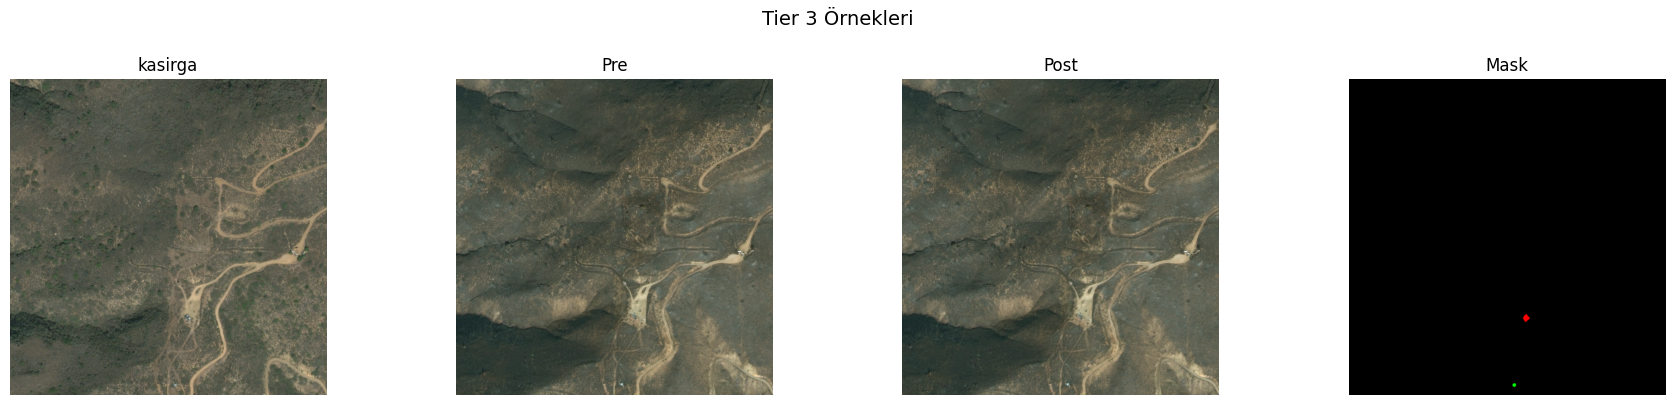


✅ Tier 3 entegrasyonu tamamlandı


In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

CMAP_V2 = ListedColormap(np.array([
    [0, 0, 0], [0, 255, 0], [255, 255, 0],
    [255, 128, 0], [255, 0, 0], [200, 0, 200]
]) / 255.0)

# Her disaster type'tan bir örnek seç
sample_per_disaster = {}
for _, row in df_tier3.iterrows():
    disaster = row["disaster_dir"] if "disaster_dir" in row else row["disaster_type"]
    if disaster not in sample_per_disaster and row.get("has_any_damage", False):
        sample_per_disaster[disaster] = row
    if len(sample_per_disaster) >= 6:
        break

n = len(sample_per_disaster)
fig, axes = plt.subplots(n, 4, figsize=(18, 4 * n))
if n == 1:
    axes = axes.reshape(1, -1)

for i, (disaster, row) in enumerate(sample_per_disaster.items()):
    pre = cv2.cvtColor(cv2.imread(row["pre_path"]), cv2.COLOR_BGR2RGB)
    post = cv2.cvtColor(cv2.imread(row["post_path"]), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

    axes[i, 0].imshow(pre)
    axes[i, 0].set_title(f"{disaster}" if i == 0 else "")
    axes[i, 0].set_ylabel(disaster, fontsize=10)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(post)
    axes[i, 1].set_title("Pre" if i == 0 else "")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(post)
    axes[i, 2].set_title("Post" if i == 0 else "")
    axes[i, 2].axis("off")

    axes[i, 3].imshow(mask, cmap=CMAP_V2, vmin=0, vmax=5)
    axes[i, 3].set_title("Mask" if i == 0 else "")
    axes[i, 3].axis("off")

plt.suptitle("Tier 3 Örnekleri", fontsize=14, y=1.001)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS_VIZ, "tier3_samples.png"), dpi=80, bbox_inches="tight")
plt.show()

print("\n✅ Tier 3 entegrasyonu tamamlandı")

## 🎉 Notebook 1c Tamamlandı!

### Drive'da

```
data/
├── raw/
│   ├── xview2/             ← Tier 1 (mevcut)
│   └── xview2_tier3/       ← YENİ
├── processed/
│   └── masks/              ← Tier 1 + Tier 3 maskeleri (birleşik)
└── splits/
    ├── file_index_v3.csv   ← YENİ (Tier 1 + Tier 3)
    ├── train_v3.csv        ← YENİ (~6500 train)
    ├── val_v3.csv          ← YENİ
    └── test_v3.csv         ← YENİ
```

### Sonraki Adım: Phase 2'yi Yeni Veri ile Eğit

Mevcut Phase 2 notebook'unu (`02_v3_phase2_damage.ipynb`) küçük bir değişiklikle çalıştırabiliriz:

**Hücre 4'te bul:**
```python
csv_path=os.path.join(DATA_SPLITS, "train_v2.csv"),
csv_path=os.path.join(DATA_SPLITS, "val_v2.csv"),
```

**Değiştir:**
```python
csv_path=os.path.join(DATA_SPLITS, "train_v3.csv"),
csv_path=os.path.join(DATA_SPLITS, "val_v3.csv"),
```

Sonra Phase 2'yi sıfırdan veya warm start ile çalıştır:
- **Sıfırdan:** Pure ablation (~10 saat). Tier 3 etkisini net görürüz.
- **Warm start:** Mevcut `teacher_v3_best_ema.pth`'i yükle, fine-tune (~5 saat). Daha hızlı.

Sana hangisini önereceğimi söyleyeyim: **Sıfırdan** çünkü:
1. Bilimsel: Tier 3 etkisini ölç
2. Modeli yeni veri dağılımına tam adapte et
3. Acelen yok dedin

### 🔥 Beklenen Sonuç

| Metric | v3 (Tier 1) | **v4 (Tier 1+3)** |
|---|---|---|
| mIoU_no_bg | 0.405 | **0.50-0.60** |
| destroyed | 0.61 | 0.65-0.70 |
| minor | 0.24 | **0.30-0.40** |
| major | 0.50 | 0.55-0.60 |

### Bana Ne Göndereceksin

1. Notebook 1c bittiğinde: Tier 3 sınıf dağılımı çıktısı
2. Yeni splitler oluştu mu doğrulama
3. Tier 3 örnekleri görseli (`tier3_samples.png`)

Sonra Phase 2'yi yeni veri ile başlatırız.

---

**Calamitas AI · Teknofest 2025 · Notebook 1c** 🚀